<a href="https://colab.research.google.com/github/anjuts006/ict_assignments/blob/main/Assignment_Data_Preprocessing_Anju.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# **1**

In [ ]:
data = pd.read_csv('/content/employee.csv')

In [ ]:
data.head()

,name,age,income,gender,department,grade,performance_score
0,Allen Smith,45.0,NaN,NaN,Operations,G3,723
1,S Kumar,NaN,16000.0,F,Finance,G0,520
2,Jack Morgan,32.0,35000.0,M,Finance,G2,674
3,Ying Chin,45.0,65000.0,F,Sales,G3,556
4,Dheeraj Patel,30.0,42000.0,F,Operations,G2,711


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   name               9 non-null      object 
 1   age                7 non-null      float64
 2   income             7 non-null      float64
 3   gender             7 non-null      object 
 4   department         9 non-null      object 
 5   grade              9 non-null      object 
 6   performance_score  9 non-null      int64  
dtypes: float64(2), int64(1), object(4)
memory usage: 636.0+ bytes


# **2**

In [ ]:
data.head()

,name,age,income,gender,department,grade,performance_score
0,Allen Smith,45.0,NaN,NaN,Operations,G3,723
1,S Kumar,NaN,16000.0,F,Finance,G0,520
2,Jack Morgan,32.0,35000.0,M,Finance,G2,674
3,Ying Chin,45.0,65000.0,F,Sales,G3,556
4,Dheeraj Patel,30.0,42000.0,F,Operations,G2,711


# **3**

In [ ]:
high_performance_employees = data[data['performance_score'] > 700]
high_performance_employees

,name,age,income,gender,department,grade,performance_score
0,Allen Smith,45.0,NaN,NaN,Operations,G3,723
4,Dheeraj Patel,30.0,42000.0,F,Operations,G2,711
7,Josh Wills,54.0,52000.0,F,Finance,G3,901
8,Leo Duck,23.0,98000.0,M,Sales,G4,709


# **4**

In [ ]:
mid_performance_employees = data[(data['performance_score'] > 500) & (data['performance_score'] < 700)]
mid_performance_employees

,name,age,income,gender,department,grade,performance_score
1,S Kumar,NaN,16000.0,F,Finance,G0,520
2,Jack Morgan,32.0,35000.0,M,Finance,G2,674
3,Ying Chin,45.0,65000.0,F,Sales,G3,556
5,Satyam Sharma,NaN,62000.0,NaN,Sales,G3,649


# **5**

In [ ]:
data.isna().sum()

,0
name,0
age,2
income,2
gender,2
department,0
grade,0
performance_score,0


In [ ]:
data['age'] = data['age'].fillna(
    data['age'].median()
    )

In [ ]:
data['income'] = data['income'].fillna(
    data['income'].median()
    )

In [ ]:
data['gender'] = data['gender'].fillna(
    data['gender'].mode()[0]
    )

In [ ]:
data.isna().sum()

,0
name,0
age,0
income,0
gender,0
department,0
grade,0
performance_score,0


# **6**

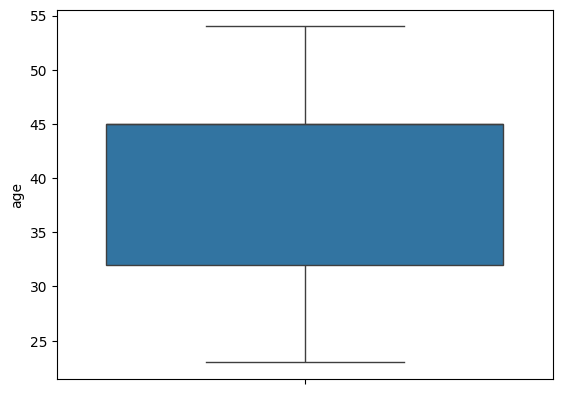

In [ ]:
sns.boxplot(data['age'])
plt.show()

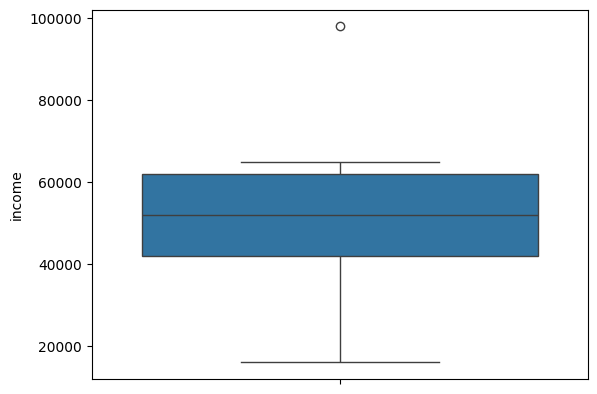

In [ ]:
sns.boxplot(data['income'])

plt.show()

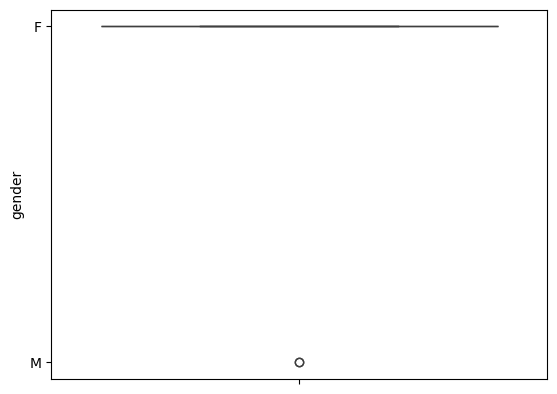

In [ ]:
sns.boxplot(data['gender'])
plt.show()

In [ ]:
lower = data['performance_score'].quantile(0.05)
upper = data['performance_score'].quantile(0.95)

print(f"Lower (5th percentile): {lower}")
print(f"Upper (95th percentile): {upper}")


Lower (5th percentile): 351.88
Upper (95th percentile): 787.0799999999999


In [ ]:
from numpy._core.defchararray import lower
q1 = data['age'].quantile(0.05)
q3 = data['age'].quantile(0.95)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper  = q3 + 1.5 * iqr

In [ ]:
print(q1,q3,lower,upper)

25.8 54.0 -16.499999999999996 96.3


In [ ]:
data['age'] = np.where(data['age'] < lower,lower,data['age'])

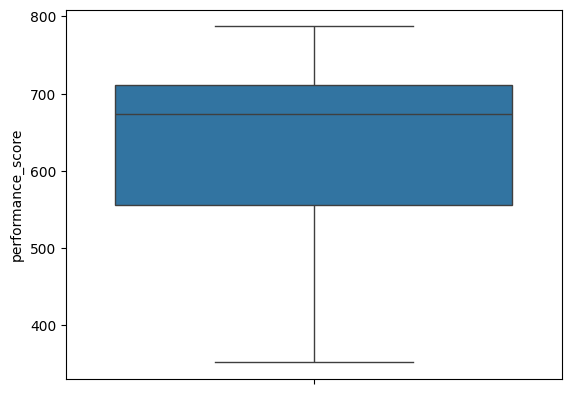

In [ ]:
sns.boxplot(y=data['performance_score'])
plt.show()

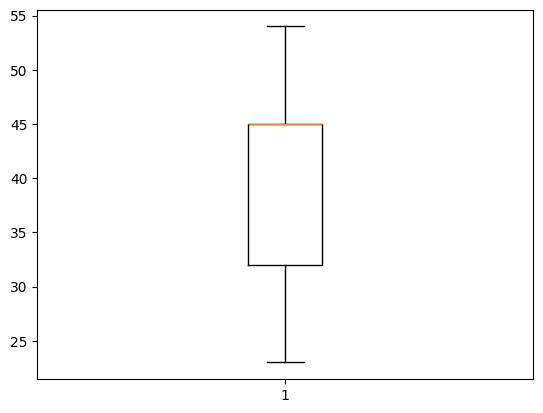

In [ ]:
plt.boxplot(data['age'])
plt.show()

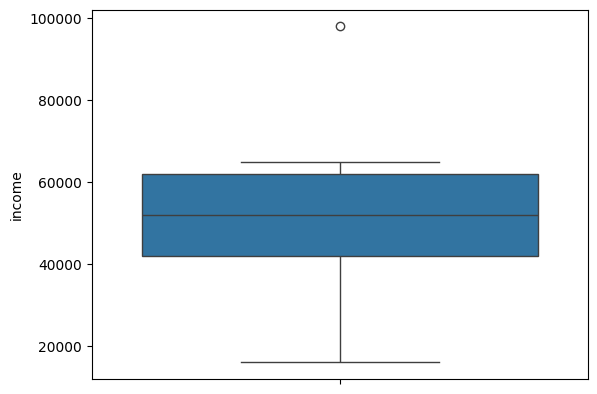

In [ ]:
sns.boxplot(data['income'])
plt.show()

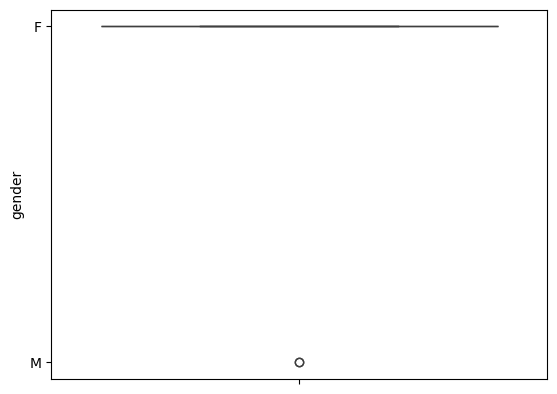

In [ ]:
sns.boxplot(data['gender'])
plt.show()

# **7**

In [ ]:
gen = {'Male':1,'Female':0}
data['gender'] = data['gender'].map(gen)
data.head()

,name,age,income,gender,department,grade,performance_score,gender_encoded
0,Allen Smith,45.0,52000.0,NaN,Operations,G3,723.0,0
1,S Kumar,45.0,16000.0,NaN,Finance,G0,520.0,0
2,Jack Morgan,32.0,35000.0,NaN,Finance,G2,674.0,1
3,Ying Chin,45.0,65000.0,NaN,Sales,G3,556.0,0
4,Dheeraj Patel,30.0,42000.0,NaN,Operations,G2,711.0,0


In [ ]:
x = data.drop(['name','gender_encoded'],axis=1)
y = data['gender_encoded']

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train = train_test_split(x,y,test_size=0.2,random_state=42)